# 5.3 전이학습

In [31]:
# 라이브러리 호출
import os
import time
import copy
import glob
import cv2 # OpenCV 라이브러리
import shutil

import torch
import torchvision # CV 용도의 패키지
import torchvision.transforms as transforms # 데이터 전처리를 위해 사용되는 패키지
import torchvision.models as models # 다양한 파이토치 네트워크를 사용할 수 있도록 도와주는 패키지
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

In [32]:
# CPU/GPU 설정
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [33]:
# 이미지 데이터 전처리 방법 정의
data_path = '/Users/eunseoshin/DL-pytorch/chap05/data/catanddog/train' # 이미지 데이터가 위치한 경로 지정

transform = transforms.Compose(
    [
        transforms.Resize([256, 256]),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ]
)

train_dataset = torchvision.datasets.ImageFolder(
    data_path,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    num_workers=8,
    shuffle=True
)

print(len(train_dataset))

385


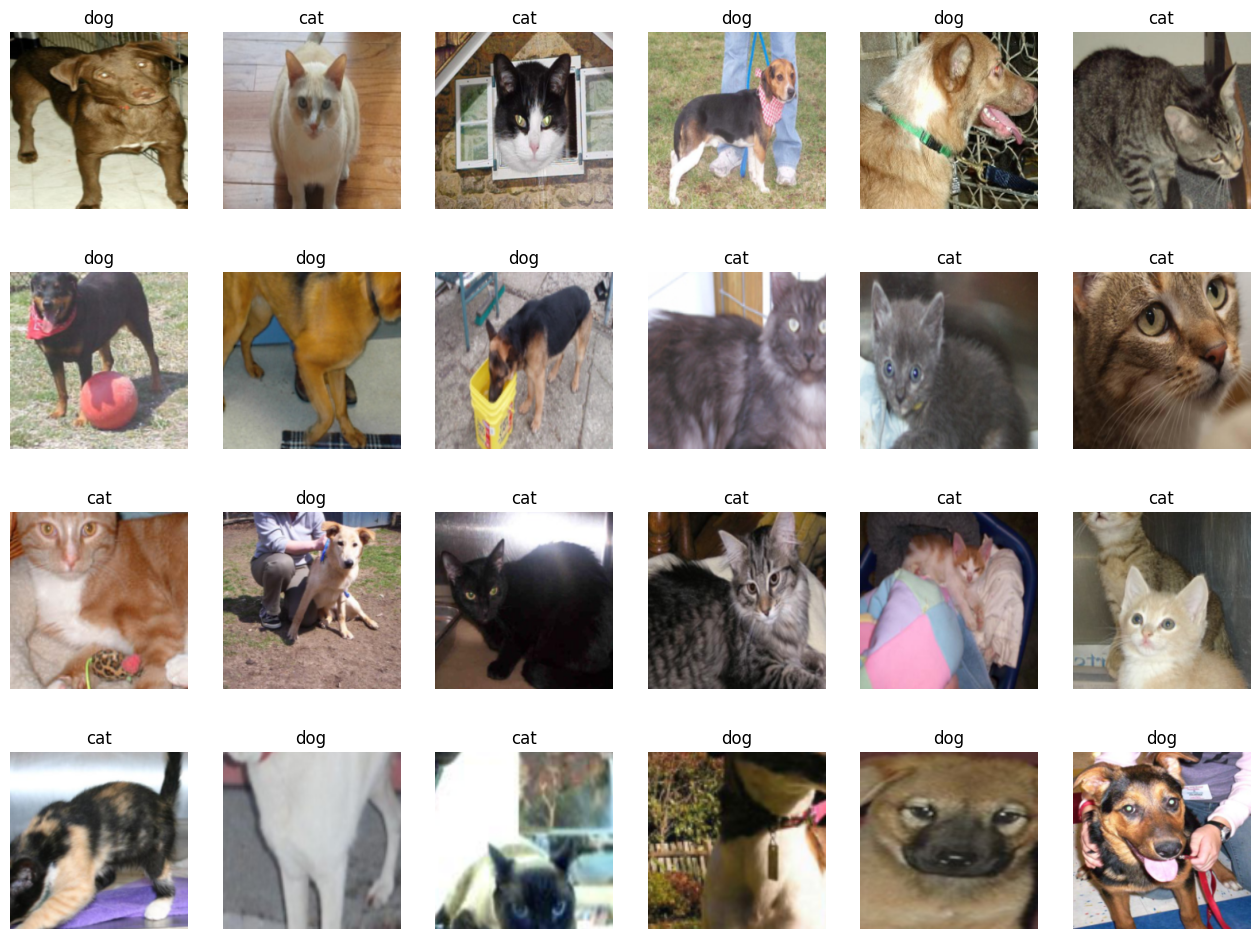

In [34]:
# 학습에 사용될 이미지 출력
samples, labels = next(iter(train_loader))
classes = {0:'cat', 1:'dog'} # 개와 고양이에 대한 클래스로 구성
fig = plt.figure(figsize=(16,24))
for i in range(24): # 24개의 이미지 데이터 출력
    a = fig.add_subplot(4,6,i+1)
    a.set_title(classes[labels[i].item()]) # 레이블 정보(클래스)를 함께 출력
    a.axis('off')
    a.imshow(np.transpose(samples[i].numpy(), (1,2,0)))
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

In [35]:
# 사전 훈련된 모델 내려받기
resnet18 = models.resnet18(pretrained=True) # pretrained=True는 사전 학습된 가중치를 사용하겠다는 의미

/opt/homebrew/Caskroom/miniforge/base/envs/dl-euron/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/dl-euron/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [36]:
# 사전 훈련된 모델의 파라미터 학습 유무 지정
def set_parameter_requires_grad(model, feature_extracting=True):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

set_parameter_requires_grad(resnet18)

In [37]:
# ResNet18에 완전연결층 추가
resnet18.fc = nn.Linear(512, 2) # 2는 클래스가 두 개라는 의미

In [38]:
# 모델의 파라미터 값 확인
for name, param in resnet18.named_parameters(): # model.named_parameters()는 모델에 접근하여 파라미터 값들을 가져올 떄 사용
    if param.requires_grad:
        print(name, param.data)

fc.weight tensor([[-0.0114,  0.0340,  0.0230,  ..., -0.0273,  0.0412,  0.0387],
        [-0.0201, -0.0057,  0.0157,  ..., -0.0253,  0.0141,  0.0060]])
fc.bias tensor([-0.0088,  0.0087])


In [39]:
# 모델 객체 생성 및 손실 함수 정의
model = models.resnet18(pretrained=True) # 모델의 객체 생성

for param in model.parameters(): # 모델의 합성곱층 가중치 고정
    param.requires_grad = False

model.fc = torch.nn.Linear(512, 2)
for param in model.fc.parameters(): # 완전연결층은 학습
    param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss() # 손실 함수 정의
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [40]:
# 모델 학습을 위한 함수 생성
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13,
                is_train=True):
    since = time.time() # 컴퓨터의 현재 시각을 구하는 함수
    acc_history = []
    loss_history = []
    best_acc = 0.0

    for epoch in range(num_epochs): # 에포크(13)만큼 반복
        print('Epoch {}/{}'.format(epoch, num_epochs-1))
        print('-' * 10)

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders: # 데이터로더에 전달된 데이터만큼 반복
            inputs = inputs.to(device)
            labels = labels.to(device)

            model.to(device)
            optimizer.zero_grad() # 기울기 0으로 설정
            outputs = model(inputs) # 순전파 학습
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward() # 역전파 학습
            optimizer.step()

            running_loss += loss.item() * inputs.size(0) # 출력 결과와 레이블의 오차를 계산한 결과를 누적하여 저장
            running_corrects += torch.sum(preds == labels.data) # 출력 결과와 레이블이 동일한지 확인한 결과를 누적하여 저장
        
        epoch_loss = running_loss / len(dataloaders.dataset) # 평균 오차 계산
        epoch_acc = running_corrects.float() / len(dataloaders.dataset) # 평균 정확도 계산

        print('Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())
        loss_history.append(epoch_loss)
        torch.save(model.state_dict(), os.path.join('/Users/eunseoshin/DL-pytorch/chap05/data/catanddog/', '{0:0=2d}.pth'.format(epoch))) # 모델 재사용을 위해 저장해두기
        print()
    
    time_elapsed = time.time() - since # 실행 시간(학습 시간)을 계산
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best Acc: {:4f}'.format(best_acc))
    return acc_history, loss_history # 모델의 정확도와 오차를 반환
            

In [41]:
# 파라미터 학습 결과를 옵티마이저에 전달
params_to_update = []
for name, param in resnet18.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param) # 파라미터 학습 결과를 저장
        print("\t", name)

optimizer = optim.Adam(params_to_update) # 학습 결과를 옵티마이저에 저장

	 fc.weight
	 fc.bias


In [42]:
# 모델 학습
criterion = nn.CrossEntropyLoss() # 손실함수 지정
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion, optimizer, device)

Epoch 0/12
----------
Loss: 0.5398 Acc: 0.7299

Epoch 1/12
----------
Loss: 0.4292 Acc: 0.7948

Epoch 2/12
----------
Loss: 0.3820 Acc: 0.8234

Epoch 3/12
----------
Loss: 0.3382 Acc: 0.8312

Epoch 4/12
----------
Loss: 0.3307 Acc: 0.8519

Epoch 5/12
----------
Loss: 0.2327 Acc: 0.8961

Epoch 6/12
----------
Loss: 0.2328 Acc: 0.9221

Epoch 7/12
----------
Loss: 0.2350 Acc: 0.9117

Epoch 8/12
----------
Loss: 0.2445 Acc: 0.8961

Epoch 9/12
----------
Loss: 0.2489 Acc: 0.8987

Epoch 10/12
----------
Loss: 0.2032 Acc: 0.9143

Epoch 11/12
----------
Loss: 0.2241 Acc: 0.8883

Epoch 12/12
----------
Loss: 0.1733 Acc: 0.9403

Training complete in 9m 33s
Best Acc: 0.940260


In [43]:
# 테스트 데이터 호출 및 전처리
test_path = '/Users/eunseoshin/DL-pytorch/chap05/data/catanddog/test'

transform = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor()
    ]
)

test_dataset = torchvision.datasets.ImageFolder(
    root=test_path,
    transform=transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)

print(len(test_dataset))

98


In [44]:
# 테스트 데이터 평가 함수 생성
def eval_model(model, dataloaders, device):
    since = time.time()
    acc_history = []
    best_acc = 0.0

    saved_models = glob.glob('/Users/eunseoshin/DL-pytorch/chap05/data/catanddog/' + '*.pth')
    saved_models.sort() # 불러온 .pth 파일들을 정렬
    print('saved_model', saved_models)

    for model_path in saved_models:
        print('Loading model', model_path)

        model.load_state_dict(torch.load(model_path))
        model.eval()
        model.to(device)
        running_corrects = 0

        for inputs, labels in dataloaders: # 테스트 반복
            inputs = inputs.to(device)
            labels = labels.to(device)

            with torch.no_grad(): # autograd를 사용하지 않겠다는 의미
                outputs = model(inputs) # 데이터를 모델에 적용한 결과를 outputs에 저장
            
            _, preds = torch.max(outputs.data, 1)
            preds[preds >= 0.5] = 1 # torch.max로 출력된 값이 0.5보다 크면 올바르게 예측
            preds[preds < 0.5] = 0 # torch.max로 출력된 값이 0.5보다 작으면 틀리게 예측
            running_corrects += preds.eq(labels).int().sum()

        epoch_acc = running_corrects.float() / len(dataloaders.dataset) # 테스트 데이터의 정확도 계산
        print('Acc: {:.4f}'.format(epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc
        acc_history.append(epoch_acc.item())
        print()

    time_elapsed = time.time() - since
    print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best Acc: {:.4f}'.format(best_acc))

    return acc_history # 계산된 정확도 반환

In [45]:
# 테스트 데이터를 평가 함수에 적용
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['/Users/eunseoshin/DL-pytorch/chap05/data/catanddog/00.pth', '/Users/eunseoshin/DL-pytorch/chap05/data/catanddog/01.pth', '/Users/eunseoshin/DL-pytorch/chap05/data/catanddog/02.pth', '/Users/eunseoshin/DL-pytorch/chap05/data/catanddog/03.pth', '/Users/eunseoshin/DL-pytorch/chap05/data/catanddog/04.pth', '/Users/eunseoshin/DL-pytorch/chap05/data/catanddog/05.pth', '/Users/eunseoshin/DL-pytorch/chap05/data/catanddog/06.pth', '/Users/eunseoshin/DL-pytorch/chap05/data/catanddog/07.pth', '/Users/eunseoshin/DL-pytorch/chap05/data/catanddog/08.pth', '/Users/eunseoshin/DL-pytorch/chap05/data/catanddog/09.pth', '/Users/eunseoshin/DL-pytorch/chap05/data/catanddog/10.pth', '/Users/eunseoshin/DL-pytorch/chap05/data/catanddog/11.pth', '/Users/eunseoshin/DL-pytorch/chap05/data/catanddog/12.pth']
Loading model /Users/eunseoshin/DL-pytorch/chap05/data/catanddog/00.pth


/var/folders/4q/3301trc50fz6_vl0qx1b71r00000gn/T/ipykernel_68941/4270964118.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path)

Acc: 0.9388

Loading model /Users/eunseoshin/DL-pytorch/chap05/data/catanddog/01.pth
Acc: 0.8367

Loading model /Users/eunseoshin/DL-pytorch/chap05/data/catanddog/02.pth
Acc: 0.9286

Loading model /Users/eunseoshin/DL-pytorch/chap05/data/catanddog/03.pth
Acc: 0.9286

Loading model /Users/eunseoshin/DL-pytorch/chap05/data/catanddog/04.pth
Acc: 0.9388

Loading model /Users/eunseoshin/DL-pytorch/chap05/data/catanddog/05.pth
Acc: 0.9286

Loading model /Users/eunseoshin/DL-pytorch/chap05/data/catanddog/06.pth
Acc: 0.9286

Loading model /Users/eunseoshin/DL-pytorch/chap05/data/catanddog/07.pth
Acc: 0.9286

Loading model /Users/eunseoshin/DL-pytorch/chap05/data/catanddog/08.pth
Acc: 0.9388

Loading model /Users/eunseoshin/DL-pytorch/chap05/data/catanddog/09.pth
Acc: 0.9592

Loading model /Users/eunseoshin/DL-pytorch/chap05/data/catanddog/10.pth
Acc: 0.9388

Loading model /Users/eunseoshin/DL-pytorch/chap05/data/catanddog/11.pth
Acc: 0.9082

Loading model /Users/eunseoshin/DL-pytorch/chap05/da

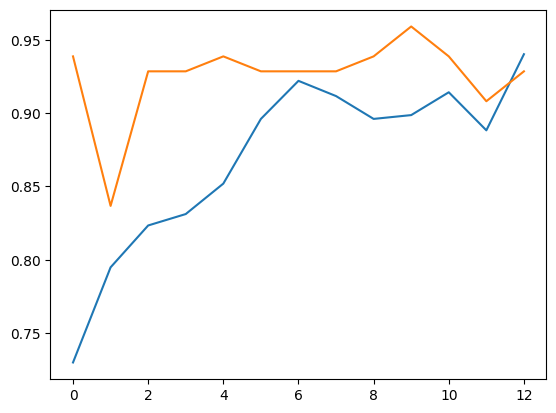

In [46]:
# 훈련과 테스트 데이터의 정확도를 그래프로 확인
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

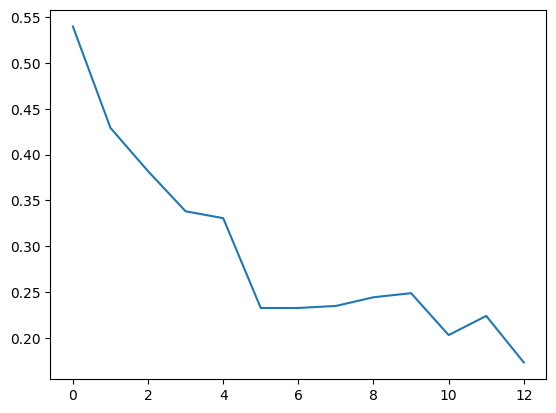

In [47]:
# 훈련 데이터의 오차에 대한 그래프 확인
plt.plot(train_loss_hist)
plt.show()

In [48]:
# 예측 이미지 출력을 위한 전처리 함수
def im_convert(tensor):
    image = tensor.clone().detach().numpy()
    image = image.transpose(1, 2, 0)
    image = image * (np.array((0.5, 0.5, 0.5)) + np.array((0.5, 0.5, 0.5)))
    image = image.clip(0, 1)
    return image

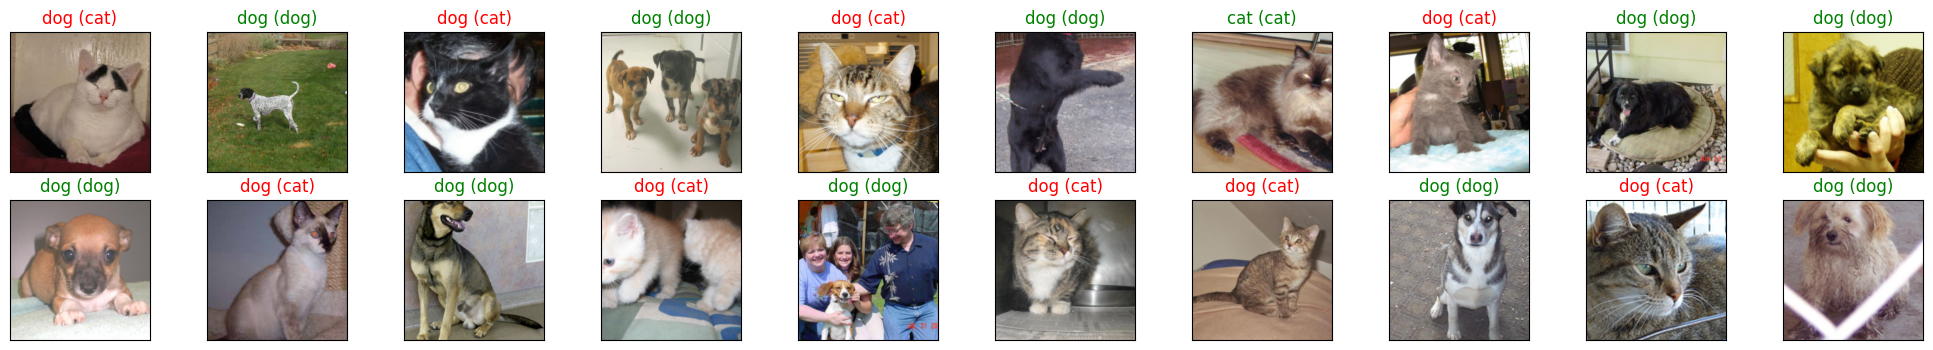

<Figure size 640x480 with 0 Axes>

In [50]:
# 개와 고양이 예측 결과 출력
classes = {0:'cat', 1:'dog'} # 개와 고양이 두 개에 대한 레이블

dataiter = iter(test_loader) # 테스트 데이터셋을 가져옴
images, labels = next(dataiter) # 테스트 데이터셋에서 이미지와 레이블을 분리하여 가져옴
model.to(device)
output = model(images.to(device))
_, pred = torch.max(output, 1)

fig = plt.figure(figsize=(25,4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
    plt.imshow(im_convert(images[idx])) # 이미지 출력을 위해 앞 셀에서 정의한 im_convert 함수 적용
    ax.set_title("{} ({})".format(str(classes[pred[idx].item()]), str(classes[labels[idx].item()])), color=("green" if pred[idx]==labels[idx] else "red"))
plt.show()
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

# 5.4 설명 가능한 CNN

In [1]:
# 필요한 라이브러리 호출
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.transforms import ToTensor
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [2]:
# 설명 가능한 네트워크 생성
class XAI(torch.nn.Module):
    def __init__(self, num_classes=2):
        super(XAI, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True), # inplace=True는 기존의 데이터를 연산의 결과값으로 대체하는 것을 의미
            nn.Dropout(0.3),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(512, 512, bias=False),
            nn.Dropout(0.5),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x) : 
        x = self.features(x)
        x = x.view(-1, 512)
        x = self.classifier(x)
        return F.log_softmax(x)

In [3]:
# 모델 객체화
model = XAI() # model이라는 이름의 객체 생성
model.to(device) # model을 device에 할당
model.eval() # 테스트 데이터에 대한 모델 평가 용도로 사용

XAI(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True

In [4]:
# 특성 맵을 확인하기 위한 클래스 정의
class LayerActivations:
    features = []
    def __init__(self, model, layer_num):
        self.hook = model[layer_num].register_forward_hook(self.hook_fn)

    def hook_fn(self, module, input, output):
        self.features = output.detach().cpu().numpy()

    def remove(self): # hook 삭제
        self.hook.remove()

torch.Size([1, 3, 100, 100])


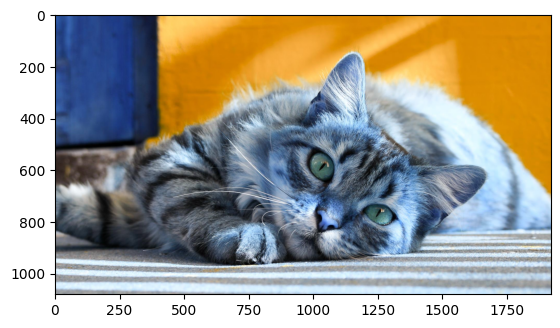

In [5]:
# 이미지 호출
img = cv2.imread("/Users/eunseoshin/DL-pytorch/chap05/data/cat.jpg")
plt.imshow(img)
img = cv2.resize(img, (100, 100), interpolation=cv2.INTER_LINEAR)
img = ToTensor()(img).unsqueeze(0).to(device)
print(img.shape)

In [6]:
# (0): Conv2d feature map 확인
result = LayerActivations(model.features, 0) # 0번째 Conv2d feature map 확인

model(img)
activations = result.features

/var/folders/4q/3301trc50fz6_vl0qx1b71r00000gn/T/ipykernel_37402/2106297184.py:76: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


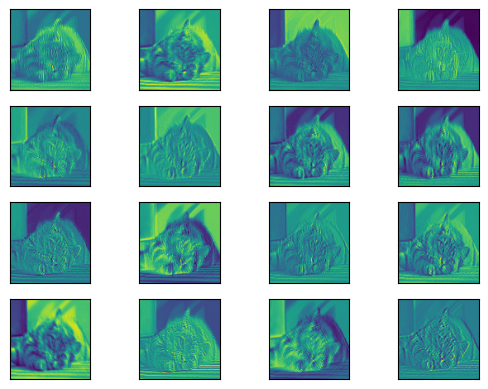

<Figure size 1200x800 with 0 Axes>

In [9]:
# feature map 확인
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12,8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row*10+column])
plt.show()

/var/folders/4q/3301trc50fz6_vl0qx1b71r00000gn/T/ipykernel_37402/2106297184.py:76: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


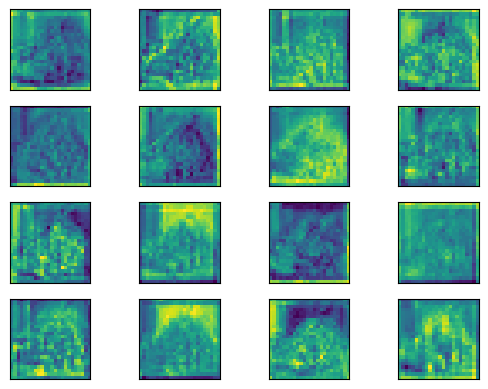

<Figure size 1200x800 with 0 Axes>

In [10]:
# 20번째 계층에 대한 feature map
result = LayerActivations(model.features, 20) # 20번째 Conv2d feature map 확인

model(img)
activations = result.features

# feature map 확인
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12,8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row*10+column])
plt.show()

/var/folders/4q/3301trc50fz6_vl0qx1b71r00000gn/T/ipykernel_37402/2106297184.py:76: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


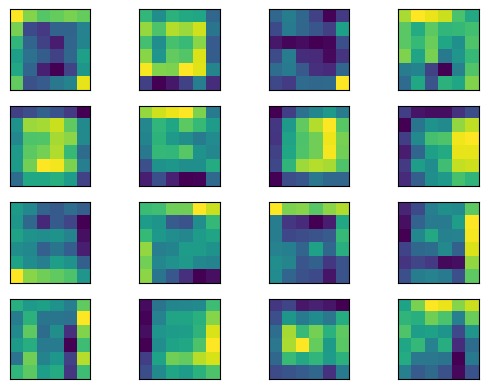

<Figure size 1200x800 with 0 Axes>

In [11]:
# 40번째 계층에 대한 feature map
result = LayerActivations(model.features, 40) # 40번째 Conv2d feature map 확인

model(img)
activations = result.features

# feature map 확인
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12,8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row*10+column])
plt.show()